In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pyproj import Proj
import math
from scipy.interpolate import interp1d
from scipy.interpolate import interp1d, PchipInterpolator, UnivariateSpline, CubicSpline
from pathlib import Path
import os



def load_and_process_data(file_path, skiprows=500, flag=False, zone=52):
    if flag:
        df = pd.read_csv(
            file_path, skiprows=skiprows, skipfooter=500,
            na_values=['', 'nan', 'NaN'], engine='python'
        ).fillna(0)
    else:
        df = pd.read_csv(
        file_path, skiprows=skiprows, skipfooter=500, engine='python'
        )
        
    df.columns = [
        'Time',
        'Accelerometer x', 'Accelerometer y', 'Accelerometer z',
        'Gyroscope x', 'Gyroscope y', 'Gyroscope z',
        'Magnetometer x', 'Magnetometer y', 'Magnetometer z',
        'Orientation x', 'Orientation y', 'Orientation z',
        'Pressure', 'Latitude', 'Longitude', 'Altitude', 'Speed_GPS'
    ]

    df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')
    start_dt = df['Time'].iloc[0]
    df['Elapsed Time'] = (df['Time'] - start_dt).dt.total_seconds()
    
    if flag:
        # (기존 원본 로직 그대로 유지)
        valid_gps_mask = (
            df['Latitude'].notna() & df['Longitude'].notna() &
            (df['Latitude'].astype(str).str.strip() != '') &
            (df['Longitude'].astype(str).str.strip() != '')
        )
        valid_lat = pd.to_numeric(df.loc[valid_gps_mask, 'Latitude'], errors='coerce')
        valid_lon = pd.to_numeric(df.loc[valid_gps_mask, 'Longitude'], errors='coerce')
        final_mask = valid_lat.notna() & valid_lon.notna()
        valid_lat = valid_lat[final_mask].values
        valid_lon = valid_lon[final_mask].values
        if len(valid_lat) == 0:
            raise ValueError("유효한 GPS 데이터가 없습니다.")
        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
        e_valid, n_valid = proj_enu(valid_lon, valid_lat)
        e_valid -= e0; n_valid -= n0
        df['E'], df['N'] = np.nan, np.nan
        df.loc[valid_gps_mask, 'E'] = e_valid
        df.loc[valid_gps_mask, 'N'] = n_valid
        e = df['E'][df['E'].notna()].values
        n = df['N'][df['N'].notna()].values
    else:
        df['Latitude']  = pd.to_numeric(df['Latitude'],  errors='coerce')
        df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
        proj_enu = Proj(proj='utm', zone=zone, ellps='WGS84', south=False)
        e_all, n_all = proj_enu(df['Longitude'].values, df['Latitude'].values)
        e0, n0 = proj_enu(df['Longitude'].iloc[0], df['Latitude'].iloc[0])
        df['E'] = e_all - e0
        df['N'] = n_all - n0
        M = len(df)
        n_sec = M // 50
        e, n = [], []
        for i in range(n_sec):
            idx = min(i*50 + 25, M-1)
            e.append(df['E'].iloc[idx])
            n.append(df['N'].iloc[idx])
        e = np.array(e)
        n = np.array(n)
            
    # ------------------------------------------------------------------
    # 5) 1Hz 궤적 보정: 초기 heading 회전 정렬
    # ------------------------------------------------------------------
    dx0, dy0 = e[1]-e[0], n[1]-n[0]
    theta0 = math.atan2(dy0, dx0)
    R0 = np.array([[math.cos(-theta0), -math.sin(-theta0)],
                    [math.sin(-theta0),  math.cos(-theta0)]])
    coords = np.vstack([e-e[0], n-n[0]])
    rotated = R0 @ coords
    e_corr, n_corr = rotated[0], rotated[1]
    
    # 1) 보간용 원본 인덱스와 타겟 인덱스 생성
    M = len(e_corr)
    t_old = np.arange(M)                          
    t_new = np.linspace(0, M - 1, (M-1)*50 + 1)          

    # 2) 선형 보간 함수 생성
    # f_e = interp1d(t_old, e_corr, kind='CubicSpline')
    # f_n = interp1d(t_old, n_corr, kind='CubicSpline')
    f_e_pchip = CubicSpline(t_old, e_corr)
    f_n_pchip = CubicSpline(t_old, n_corr)
    
    # 3) 50개 포인트로 보간
    e_aug = f_e_pchip(t_new)   # shape = (50,)
    n_aug = f_n_pchip(t_new)   # shape = (50,)
    
    # df['e_aug'] = e_aug
    # df['n_aug'] = n_aug
    
    df2 = df.iloc[:len(e_aug)].copy()

    # 2) 그 위에 보간 결과를 할당
    df2['e_aug'] = e_aug
    df2['n_aug'] = n_aug
    
    e = df2['e_aug'].values  # shape = (T,)
    n = df2['n_aug'].values  # shape = (T,)

    window_size = 150  # 1초 = 50샘플
    num_wins = len(e) - window_size + 1

    
    # 결과 저장용
    y_speed = np.zeros(num_wins)
    y_dh    = np.zeros(num_wins)
    
    delta_head = np.arctan2(
        np.diff(n_aug), np.diff(e_aug)
    )
    cum_head = np.cumsum(np.unwrap(delta_head))
    # plt.plot(cum_head)
    # plt.show()
    
    temp = []

    for i in range(num_wins):
        we = e[i : i+window_size]   # window of Eastings
        wn = n[i : i+window_size]   # window of Northings

        # 1) 속도: 시작점→종료점 직선 이동 거리 (m/s)
        dx = we[-1] - we[0]
        dy = wn[-1] - wn[0]
        dist = np.hypot(dx, dy)    # sqrt(dx^2 + dy^2)
        y_speed[i] = dist          # 1초 동안 이동거리 = 속도(m/s)

        # 2) 방향변화량: 각 샘플 간 heading 변화를 누적
        
        headings = np.arctan2(np.diff(wn), np.diff(we))
        headings = np.unwrap(headings)

        # Δheading 원본
        raw_delta = headings[-1] - headings[0]
        temp.append(raw_delta)
        
        # 윈도우 내 실질적인 회전량 (sum of abs)
        dh = np.diff(headings)
        total_delta = np.sum(dh)

        # # 소프트 데드존 적용
        # if abs(raw_delta) < threshold:
        #     delta = 0
        # else:
        #     delta = np.sign(raw_delta) * (abs(raw_delta) - threshold)

        y_dh[i] = total_delta
        
    # plt.plot(np.degrees(temp), '.-', label='Raw Delta Heading')
    # plt.plot(np.degrees(y_dh), '.-', label='Total Delta Heading')
    # plt.legend()
    # plt.show()
        
    sensor_cols = ['Accelerometer x','Accelerometer y','Accelerometer z',
            'Gyroscope x','Gyroscope y','Gyroscope z']
    sensor = df2[sensor_cols].values  # shape = (T,6)

    X = np.zeros((num_wins, window_size, 6))
    for i in range(num_wins):
        X[i] = sensor[i : i+window_size]

    # (2) Y 결합
    Y = np.vstack([y_speed, y_dh]).T   # shape = (num_wins, 2)
    
    # plt.plot(y_dh[:1000], '.-')
    # plt.show()
    
    # Initialize arrays for reconstructed path
    path_e = np.zeros(len(y_speed))
    path_n = np.zeros(len(y_speed))
    current_heading = 0

    # Reconstruct path from speed and heading changes
    for i in range(len(y_speed)):
        # Update heading
        current_heading += (y_dh[i] * 0.02)
        
        # Calculate displacement using speed and heading
        dx = (y_speed[i]*0.02) * np.cos(current_heading)
        dy = (y_speed[i]*0.02) * np.sin(current_heading)
        
        # Update position
        if i > 0:
            path_e[i] = path_e[i-1] + dx
            path_n[i] = path_n[i-1] + dy

    # Plot original and reconstructed paths
    plt.figure(figsize=(10, 8))
    plt.plot(e, n, 'b.-', label='Original Path')
    plt.plot(e_corr, n_corr, 'r.-')
    #plt.plot(path_e, path_n, 'r.-', label='Reconstructed Path')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.xlabel('East (m)')
    plt.ylabel('North (m)')
    plt.title('Original vs Reconstructed Path')
    plt.show()

        
    return df2, X, Y

=== SWING 데이터 ===


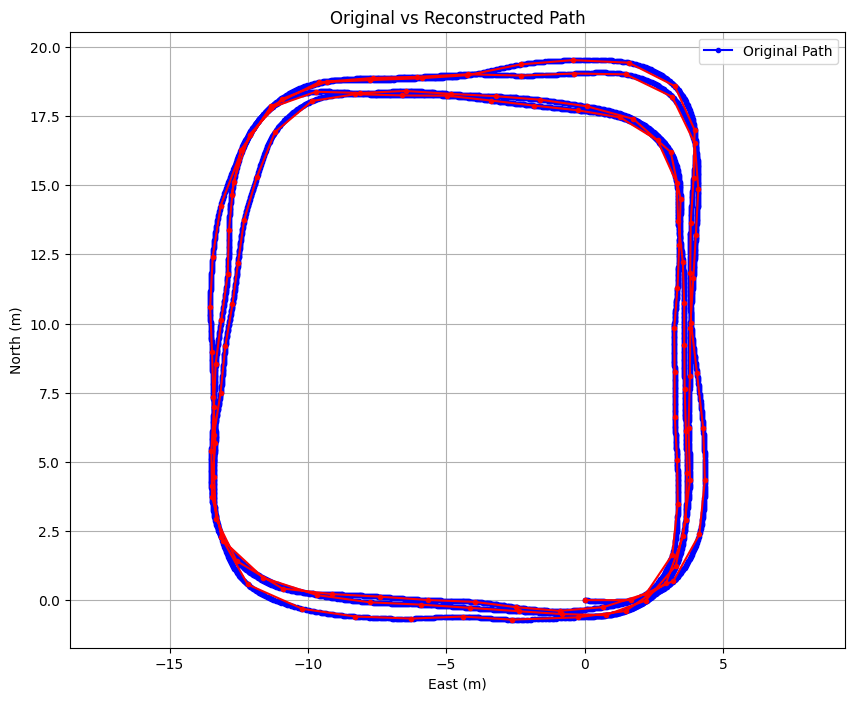

[01] swing_left01.csv                 길이:   6751  ≈   2.25 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}
--> 그룹 합계: 2.25 분

=== LOOKING 데이터 ===


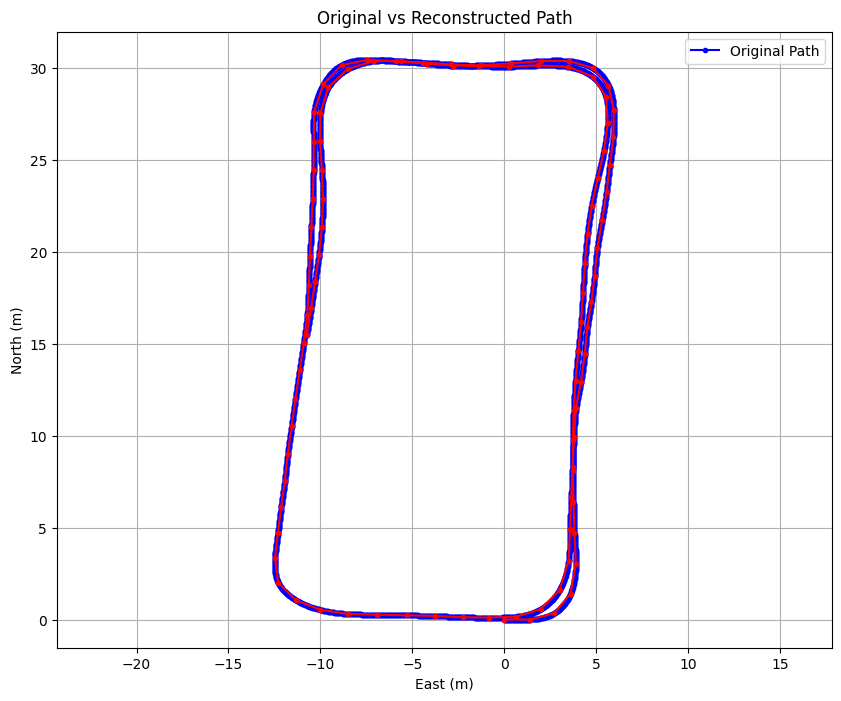

[01] looking_left01.csv               길이:   4901  ≈   1.63 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


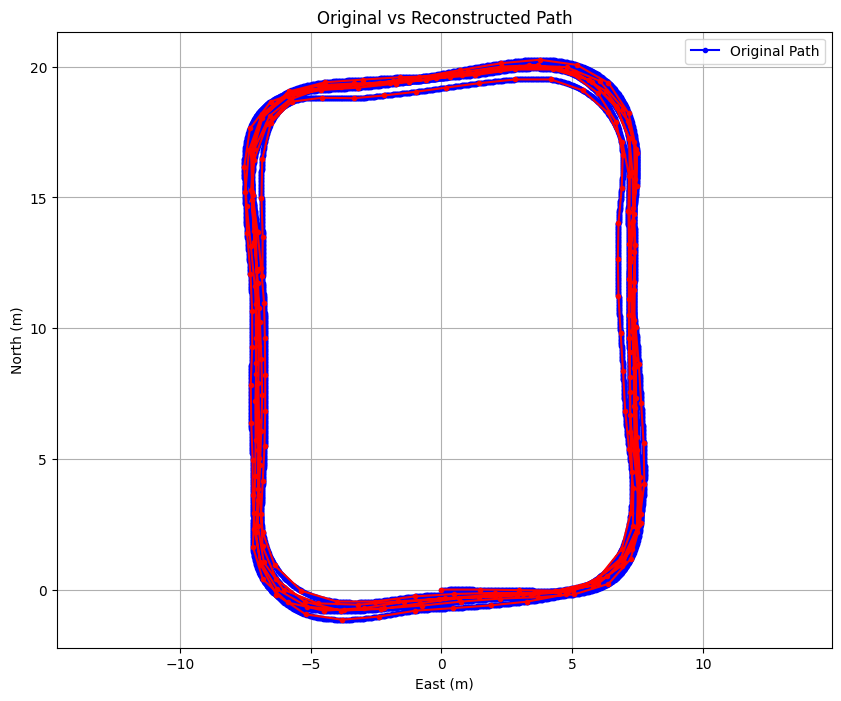

[02] looking_left03.csv               길이:  15101  ≈   5.03 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


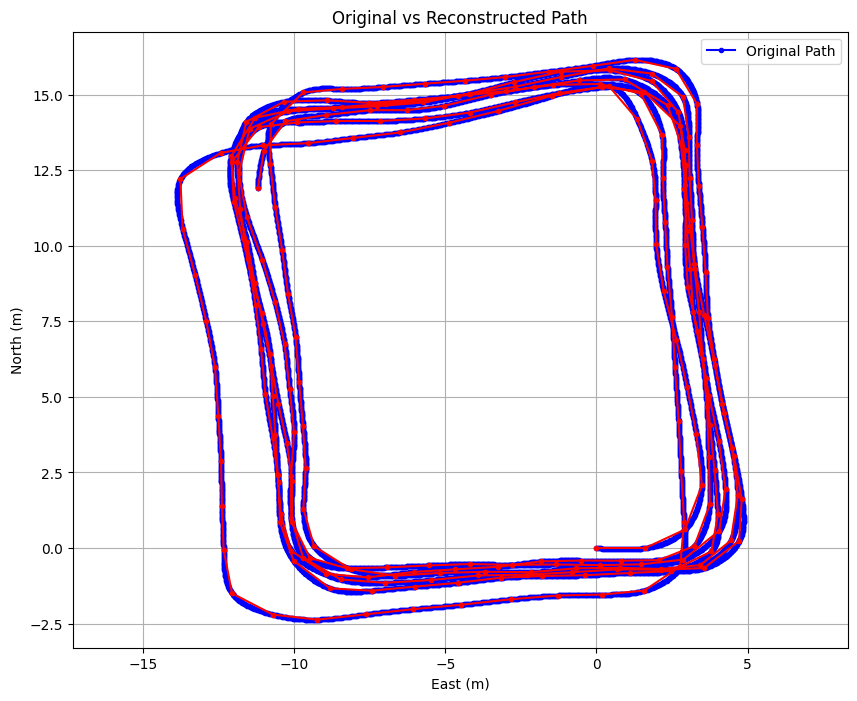

[03] looking_left04.csv               길이:  13151  ≈   4.38 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


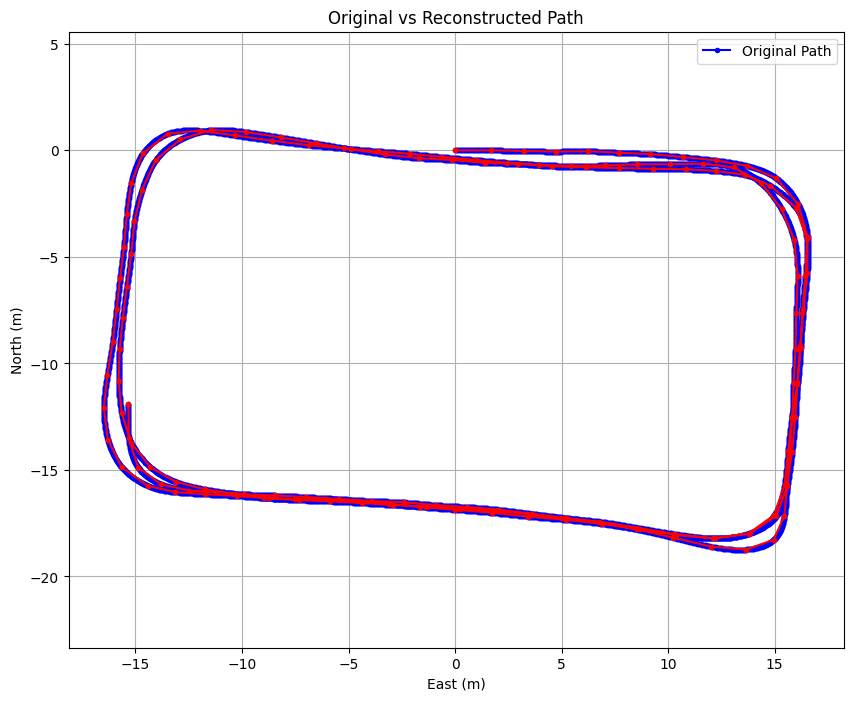

[04] looking_right01.csv              길이:   8001  ≈   2.67 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


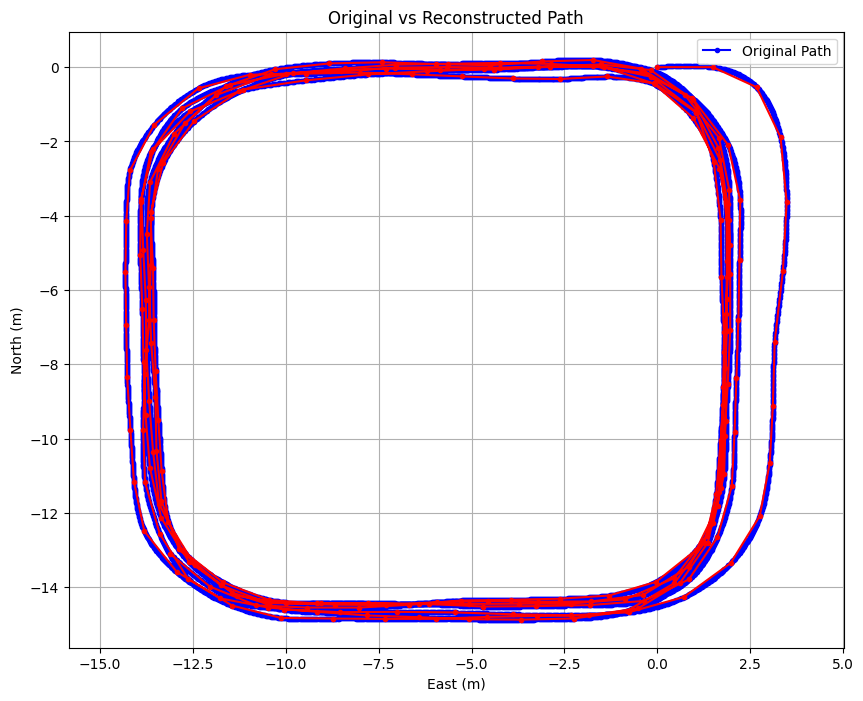

[05] looking_right02.csv              길이:  12401  ≈   4.13 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


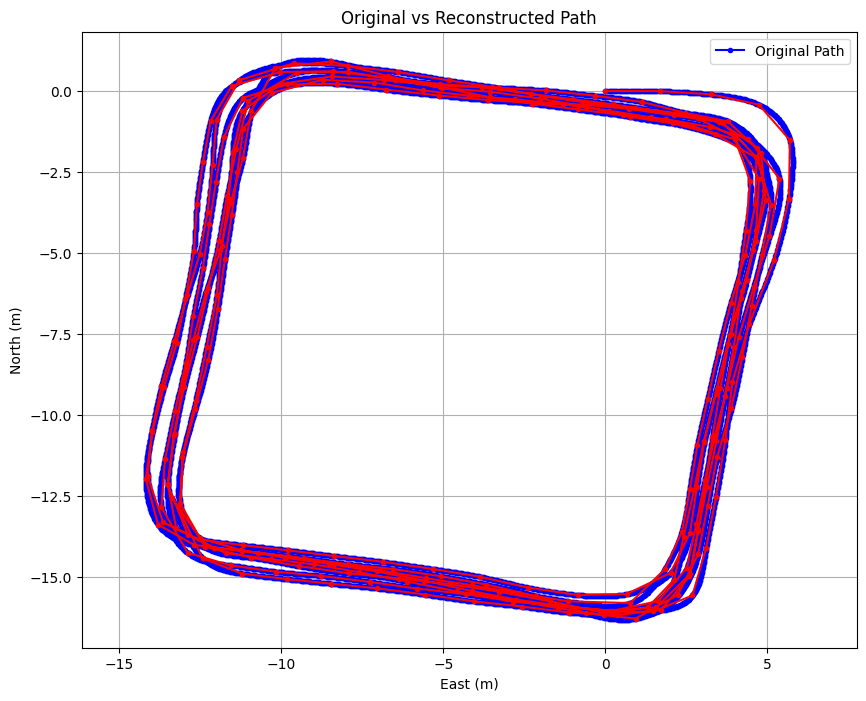

[06] looking_right03.csv              길이:  15301  ≈   5.10 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


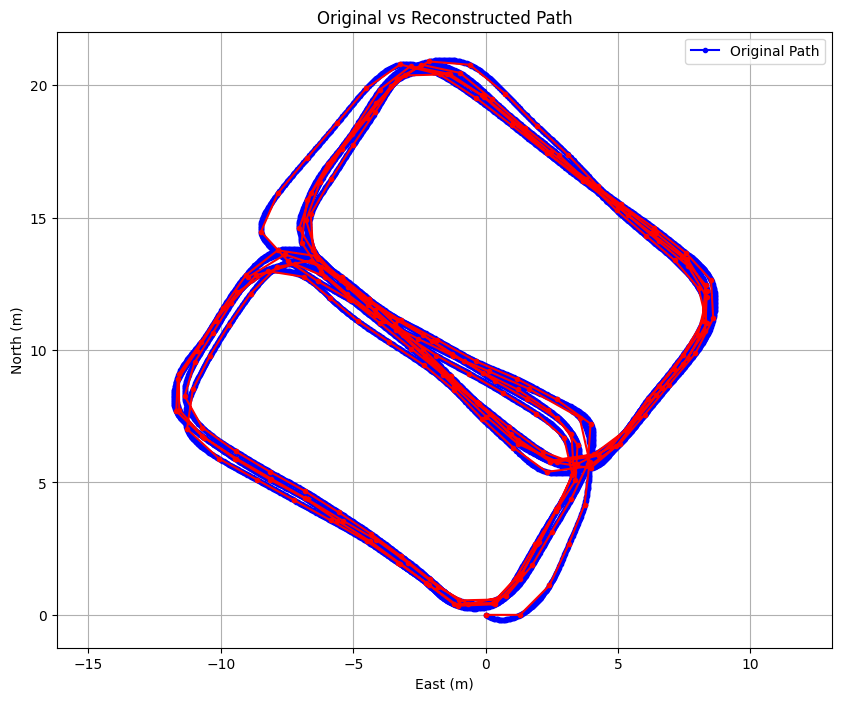

[07] looking_lr01.csv                 길이:  14001  ≈   4.67 분  opts={'skiprows': 500, 'flag': False, 'zone': 52}


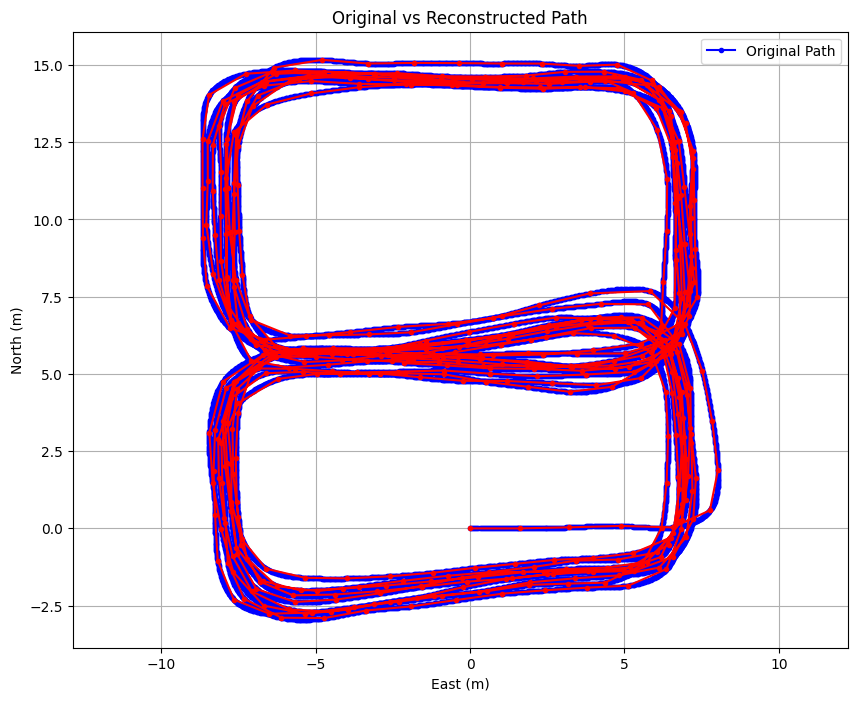

[08] looking_lr02.csv                 길이:  29851  ≈   9.95 분  opts={'skiprows': 500, 'flag': True, 'zone': 52}
--> 그룹 합계: 37.57 분

요약) SWING: 2.25 분 | LOOKING: 37.57 분 | 총합: 39.82 분

=== SWING ===
file                                 min  tag         left_min  right_min
swing_left01.csv                    2.25  left            2.25       0.00
-- 합계: left=2.25 min | right=0.00 min | total=2.25 min

=== LOOKING ===
file                                 min  tag         left_min  right_min
looking_left01.csv                  1.63  left            1.63       0.00
looking_left03.csv                  5.03  left            5.03       0.00
looking_left04.csv                  4.38  left            4.38       0.00
looking_right01.csv                 2.67  right           0.00       2.67
looking_right02.csv                 4.13  right           0.00       4.13
looking_right03.csv                 5.10  right           0.00       5.10
looking_lr01.csv                    4.67  lr(50/50)       2.33   

In [3]:
# 파일별 옵션 (파일명 기준 override)
config = {
    'looking_left05.csv': {'skiprows': 500, 'flag': True,  'zone': 52},
    'looking_lr02.csv':   {'skiprows': 500, 'flag': True,  'zone': 52},
    'UTAH_looking_01.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    'UTAH_looking_02.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    'UTAH_looking_03.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
    'UTAH_looking_04.csv':{'skiprows': 1000,'flag': True,  'zone': 12},
}
default_config = {'skiprows': 500, 'flag': False, 'zone': 52}

# =========================
# 전역 설정
# =========================
BASE_DIR = os.getcwd()
FS = 50  # Hz

# 학습 데이터 경로들
swing_learnData_path = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left01.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left02.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_left03.csv'),
    
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right01.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right02.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_right03.csv'),

    # os.path.join(BASE_DIR, 'data', 'learn_data', 'swing', 'swing_lr01.csv'),
]

looking_learnData_path = [
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left01.csv'),
    #os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left03.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left04.csv'),
    #os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_left05.csv'), 

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_right01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_right02.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_right03.csv'),

    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr01.csv'),
    os.path.join(BASE_DIR, 'data', 'learn_data', 'looking','looking_lr02.csv'),

    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_01.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_02.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_03.csv'),
    # os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_04.csv'),
]



# =========================
# 그룹 로딩 & 길이 합산
# =========================
def load_group(paths, loader_fn, cfg=None, default_cfg=None, fs=FS):
    """
    한 그룹(paths) 로드/전처리, 파일별 옵션 자동 적용.
      - loader_fn(path, **opts) -> (df, X, Y)
      - cfg: 파일명별 옵션 dict
      - default_cfg: 기본 옵션 dict
    """
    cfg = cfg or {}
    default_cfg = default_cfg or {}
    df_list, X_list, Y_list = [], [], []
    total_min = 0.0

    for idx, p in enumerate(paths, start=1):
        fname = Path(p).name
        opts = {**default_cfg, **cfg.get(fname, {})}  # default + per-file override

        try:
            df_temp, X_temp, Y_temp = loader_fn(p, **opts)
        except Exception as e:
            print(f'[에러] {fname}: {e}')
            continue

        df_list.append(df_temp)
        X_list.append(X_temp)
        Y_list.append(Y_temp)

        minutes = len(df_temp) / fs / 60.0
        print(f'[{idx:02d}] {fname:<32} 길이:{len(df_temp):7d}  ≈ {minutes:6.2f} 분  opts={opts}')
        total_min += minutes

    print(f'--> 그룹 합계: {total_min:.2f} 분\n')
    return df_list, X_list, Y_list, total_min

# =========================
# 좌/우/혼합 분량 요약
# =========================
def summarize_turn_minutes(df_list, paths, fs=FS):
    """
    df_list: 각 파일의 DataFrame 리스트
    paths  : 각 파일의 경로 리스트 (df_list와 동일 순서)
    fs     : 샘플링 주파수(Hz)
    return : (per_file_rows, totals)
    """
    rows = []
    tot_left = 0.0
    tot_right = 0.0
    for df, p in zip(df_list, paths):
        fname = Path(p).name
        name = fname.lower()
        minutes = len(df) / fs / 60.0

        if ("lr" in name) or ("left" in name and "right" in name):
            # 혼합 데이터 → 좌/우 반반
            left_min = minutes / 2.0
            right_min = minutes / 2.0
            tag = "lr(50/50)"
        elif "left" in name:
            left_min = minutes
            right_min = 0.0
            tag = "left"
        elif "right" in name:
            left_min = 0.0
            right_min = minutes
            tag = "right"
        else:
            left_min = 0.0
            right_min = 0.0
            tag = "unknown"

        tot_left += left_min
        tot_right += right_min
        rows.append({
            'file': fname,
            'minutes': round(minutes, 2),
            'tag': tag,
            'left_min': round(left_min, 2),
            'right_min': round(right_min, 2),
        })

    totals = {
        'left': round(tot_left, 2),
        'right': round(tot_right, 2),
        'total': round(tot_left + tot_right, 2),
    }
    return rows, totals

def pretty_print_summary(title, rows, totals):
    print(f"\n=== {title} ===")
    print(f"{'file':32} {'min':>7}  {'tag':10} {'left_min':>9} {'right_min':>10}")
    for r in rows:
        print(f"{r['file']:<32} {r['minutes']:7.2f}  {r['tag']:<10} {r['left_min']:9.2f} {r['right_min']:10.2f}")
    print(f"-- 합계: left={totals['left']:.2f} min | right={totals['right']:.2f} min | total={totals['total']:.2f} min")

# (선택) 판다스 표/CSV 저장
def to_dataframe(rows):
    return pd.DataFrame(rows, columns=['file','minutes','tag','left_min','right_min'])

def save_summary_csv(prefix, rows, totals, out_dir="outputs"):
    os.makedirs(out_dir, exist_ok=True)
    df = to_dataframe(rows)
    df.to_csv(os.path.join(out_dir, f"{prefix}_per_file.csv"), index=False, encoding="utf-8-sig")
    pd.DataFrame([totals]).to_csv(os.path.join(out_dir, f"{prefix}_totals.csv"), index=False, encoding="utf-8-sig")

# =========================
# 실행부
# =========================
if __name__ == "__main__":
    loader1 = lambda path, **opts: load_and_process_data(path, **opts)

    print('=== SWING 데이터 ===')
    swing_df_list, swing_X_list, swing_Y_list, swing_min = load_group(
        swing_learnData_path, loader_fn=loader1, cfg=config, default_cfg=default_config
    )

    print('=== LOOKING 데이터 ===')
    looking_df_list, looking_X_list, looking_Y_list, looking_min = load_group(
        looking_learnData_path, loader_fn=loader1, cfg=config, default_cfg=default_config
    )

    print(f'요약) SWING: {swing_min:.2f} 분 | LOOKING: {looking_min:.2f} 분 | 총합: {swing_min + looking_min:.2f} 분')

    # 좌/우/혼합 분량 요약
    swing_rows, swing_tot = summarize_turn_minutes(swing_df_list, swing_learnData_path, fs=FS)
    pretty_print_summary("SWING", swing_rows, swing_tot)

    looking_rows, looking_tot = summarize_turn_minutes(looking_df_list, looking_learnData_path, fs=FS)
    pretty_print_summary("LOOKING", looking_rows, looking_tot)

    # 전체 합산
    all_rows = swing_rows + looking_rows
    all_tot = {
        'left':  round(swing_tot['left']  + looking_tot['left'],  2),
        'right': round(swing_tot['right'] + looking_tot['right'], 2),
        'total': round(swing_tot['total'] + looking_tot['total'], 2),
    }
    pretty_print_summary("전체(SWING + LOOKING)", all_rows, all_tot)